In [6]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 使用fetch_california_housing获取加利福尼亚房价数据
data = fetch_california_housing(data_home='data')
# 转为DataFrame查看一下
df = pd.DataFrame(data.data, columns=data.feature_names)
# 添加标签列
df['price'] = data.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

# 分割特征和标签
X = df.drop('price', axis=1).values
y = df['price'].values
print(y.shape)
# 划分训练集和测试集（80%训练 20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import StandardScaler

# 对特征数据进行标准化 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


from sklearn.linear_model import LinearRegression

# 使用LinearRegression训练线性回归模型
lr = LinearRegression()
lr.fit(X_train, y_train)

# 打印回归系数
print("回归系数:", lr.coef_)
print("截距项:", lr.intercept_)

# 预测
y_pred = lr.predict(X_test)

# 评估：计算均方误差 MSE
mse = np.mean((y_pred - y_test) ** 2)
print(f"正规方程测试集均方误差 MSE: {mse}")


(20640,)
回归系数: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
截距项: 2.071946937378619
正规方程测试集均方误差 MSE: 0.5558915986952442


In [8]:
X_train

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]], shape=(16512, 8))

In [9]:
y_train

array([1.03 , 3.821, 1.726, ..., 2.221, 2.835, 3.25 ], shape=(16512,))

In [10]:
from sklearn.linear_model import SGDRegressor

# learning_rate的不同方式，代表学习率变化的算法不一样,比如constant,invscaling,adaptive
# 默认可以去调 eta0 = 0.008，会改变learning_rate的初始值
# learning_rate='optimal',alpha是正则化力度，但是会影响学习率的值，由alpha来算学习率
# learning_rate变化方式：constant,optimal,invscaling,adaptive
# invscaling代表学习率随着迭代次数的增加而减小
# penalty代表正则化，分为l1和l2
# eta0=0.01, penalty='l2',max_iter=1000
sgd_reg = SGDRegressor(eta0=0.01,penalty='l2', max_iter=1000)

# 训练模型
sgd_reg.fit(X_train, y_train)

# 打印回归系数和截距
print("SGD回归系数:", sgd_reg.coef_)
print("SGD截距项:", sgd_reg.intercept_)

# 预测
y_pred_sgd = sgd_reg.predict(X_test)

# 评估：计算均方误差 MSE
mse_sgd = np.mean((y_pred_sgd - y_test) ** 2)
print(f"SGDRegressor测试集均方误差 MSE: {mse_sgd}")


SGD回归系数: [ 7.95774454e-01  1.14127089e-01 -1.93096459e-01  2.65542589e-01
 -6.35802574e-04 -2.11475672e-01 -1.00495618e+00 -9.92062946e-01]
SGD截距项: [2.07579942]
SGDRegressor测试集均方误差 MSE: 0.5504793241617233


# 对于SGD必须进行标准化，为什么

➡ 特征值大的维度（如 Population）会主导梯度
➡ 小尺度特征几乎“失声”
➡ 参数更新方向严重失衡
➡ 模型学不好

# Lasso 回归

In [11]:
from sklearn.linear_model import Lasso

# 创建Lasso回归模型，可以设置alpha控制正则化强度
lasso_reg = Lasso(alpha=0.001)
# 训练模型
lasso_reg.fit(X_train, y_train)

# 打印回归系数
print("Lasso回归系数:", lasso_reg.coef_)

# 预测
y_pred_lasso = lasso_reg.predict(X_test)

# 评估：计算均方误差 MSE
mse_lasso = np.mean((y_pred_lasso - y_test) ** 2)
print(f"Lasso回归测试集均方误差 MSE: {mse_lasso}")


Lasso回归系数: [ 0.84914038  0.12334631 -0.28127333  0.32604963 -0.00106185 -0.03988954
 -0.88582217 -0.85809324]
Lasso回归测试集均方误差 MSE: 0.5544913600832686


In [12]:
np.random.seed(22)
# 1. 准备数据X,y 增加噪声
# 创建100个数据,在[-3,3]中取值,值是均匀分布的
x = np.random.uniform(-3, 3, size=100)
x

array([-1.74923678, -0.10991363, -0.47677179,  2.15509199, -1.97303068,
       -0.96681624, -1.376803  ,  1.1462481 , -1.6775729 ,  1.87170552,
       -2.93683875,  0.36722218,  1.88235712,  1.47060178, -1.86533187,
       -2.9631548 ,  1.63226323,  2.74699301,  1.2116273 , -1.2145304 ,
        1.60795645,  1.12930995, -0.67689912,  0.69123495, -0.43466856,
        0.50573786,  1.21581311, -2.32862897,  2.53961956,  2.93331764,
        1.06446464,  1.77098865, -2.8255419 , -1.93344557,  2.24956647,
        1.46959246,  0.04854098, -2.22999659, -0.09429457,  0.09464093,
       -1.13241202, -2.72603074, -0.37391604, -2.42469234, -2.72873933,
        1.10897231,  2.09514447, -2.2487569 , -2.22561596, -0.16163999,
       -1.81464895,  1.68973649,  0.64448318, -0.33899943,  2.89217465,
        1.25373248, -1.68761751, -1.99507021,  0.23259284, -1.11947527,
        2.46922198, -2.48246592, -1.11555582, -1.68517583,  1.41999738,
        1.97124219,  1.46738678, -1.93477777,  2.15071918, -2.96

X的形状: (100, 1)
多项式扩展后X2的形状: (100, 10)
Ridge回归MSE: 0.8340220252344763
Ridge回归权重w: [ 9.61199650e-01  1.03752625e+00 -4.41366376e-01 -2.45484025e-01
  2.81460639e-01  3.49426802e-02 -5.58289858e-02 -5.58964522e-05
  3.38758035e-03 -1.84530373e-04]


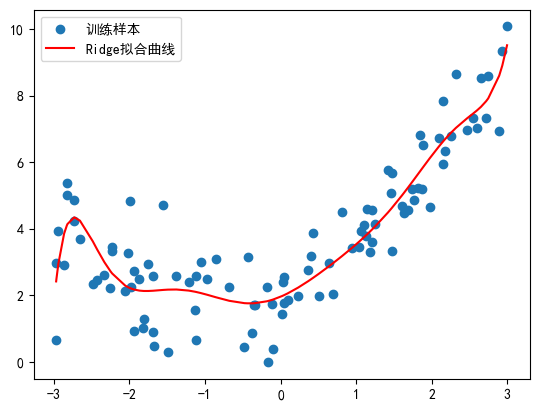

array([ 9.61199650e-01,  1.03752625e+00, -4.41366376e-01, -2.45484025e-01,
        2.81460639e-01,  3.49426802e-02, -5.58289858e-02, -5.58964522e-05,
        3.38758035e-03, -1.84530373e-04])

In [28]:
# 岭回归示例，演示如何使用Ridge回归拟合高阶多项式特征的数据，并进行评估和可视化

from sklearn.linear_model import Ridge          # 导入岭回归模型
from sklearn.metrics import mean_squared_error  # 导入均方误差评价指标
from matplotlib import pyplot as plt            # 导入绘图库

# 1. 创建数据
np.random.seed(22)  # 设置随机种子，确保实验结果可复现

# 生成100个均匀分布在[-3, 3]之间的浮点数, 作为特征x
x = np.random.uniform(-3, 3, size=100)

# 构造标签y, 真实关系为y = 0.5x^2 + x + 2, 加上均值为0、方差为1的正态分布噪声模拟现实场景误差
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, size=100)

# 2. 创建岭回归模型
# alpha为正则化参数，默认为1.0。可根据需要调整
model = Ridge()

# 3. 模型训练
# Ridge要求输入为二维特征，因此需要将x reshape为(n_samples, 1)形状
# -1表示行数自动推断，1表示一列
X = x.reshape(-1, 1)
print("X的形状:", X.shape)  # (100, 1)

# 堆叠多项式特征（x, x^2, ..., x^10），模拟高阶回归，np.hstack按列拼接
X2 = np.hstack([X, X ** 2, X ** 3, X ** 4, X ** 5, X ** 6, X ** 7, X ** 8, X ** 9, X ** 10])
print("多项式扩展后X2的形状:", X2.shape)  # (100, 10)

# 在多项式特征上训练岭回归模型
model.fit(X2, y)

# 4. 模型预测
# 用同样的高阶多项式特征做预测
y_predict = model.predict(X2)

# 5. 模型评估
# 用均方误差评价预测效果
mse = mean_squared_error(y, y_predict)
print("Ridge回归MSE:", mse)
print("Ridge回归权重w:", model.coef_)  # 打印岭回归各阶特征的权重

# 6. 绘制图像，直观展示拟合效果
plt.scatter(x, y, label="训练样本")  # 原始数据点，散点图
# 绘制预测曲线（红色），x需要先排序，y_predict也需要按x排序
plt.plot(np.sort(x), y_predict[np.argsort(x)], color='r', label="Ridge拟合曲线")
plt.legend()  # 展示图例
plt.show()

# 输出岭回归模型的权重系数
model.coef_

(100, 1)
(100, 10)
线性回归MSE: 0.8144736129032126
线性回归权重w: [ 1.48390146e+00  1.91708406e+00 -1.09189930e+00 -9.60331272e-01
  5.22612600e-01  2.48127460e-01 -9.01884785e-02 -2.65810071e-02
  5.04735223e-03  9.83074618e-04]


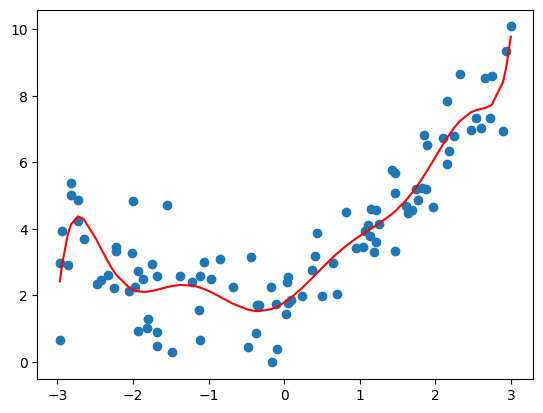

array([ 1.48390146e+00,  1.91708406e+00, -1.09189930e+00, -9.60331272e-01,
        5.22612600e-01,  2.48127460e-01, -9.01884785e-02, -2.65810071e-02,
        5.04735223e-03,  9.83074618e-04])

In [14]:
# 2. 创建模型
# 线性回归，不加正则
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# 3. 模型训练
# 训练数据是二维的,所以X需要reshape成二维的
# -1的作用是告诉numpy,根据y的维度自动确定X的维度
# 1 是列数
X = x.reshape(-1,1)
print(X.shape)

# 堆叠，增加多次项
X2 = np.hstack([X,X ** 2, X ** 3, X ** 4, X ** 5, X ** 6, X ** 7, X ** 8, X ** 9, X ** 10])
print(X2.shape)

model.fit(X2,y)

# 4. 模型预测
y_predict = model.predict(X2)

# 5. 模型评估
mse = mean_squared_error(y,y_predict)
print("线性回归MSE:", mse)
print("线性回归权重w:", model.coef_)

# 6. 绘制图像
plt.scatter(x,y)	
# # 画图plot折线图时 需要对x进行排序, 取x排序后对应的y值
plt.plot(np.sort(x), y_predict[np.argsort(x)], color='r')
plt.show()
model.coef_

(100,)
(100,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(100, 1)
欠拟合模型MSE: 2.7365298290204287


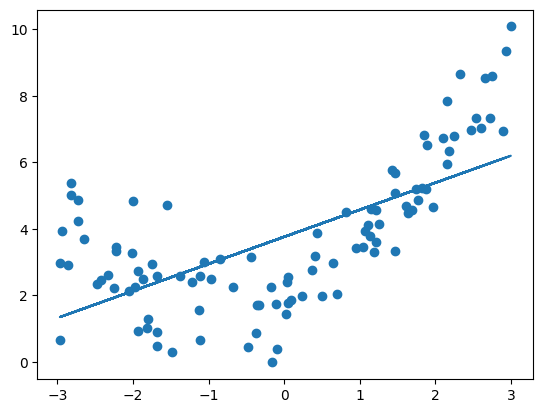

In [18]:
import numpy as np
def under_fitting():
    #随机种子
    np.random.seed(22)
    #1.准备数据X,y增加噪声
    #创建100个数据,在[-3,3]中取值,值是均匀分布的
    X=np.random.uniform(-3,3,size=100)
    #y=0.5x^2+x+2
    #np.random.normal(0,1,size=100):增加噪声,噪声值为均值为0,方差为1的正态分布数据
    y=0.5*X**2+X+2+np.random.normal(0,1,size=100)
    #2.训练模型
    model=LinearRegression()
    print(X.shape)
    print(y.shape)
    print(type(X))
    print(type(y))

    #3.模型训练
    #训练数据是二维的,所以X需要reshape成二维的
    #-1的作用是告诉numpy,根据y的维度自动确定X的维度
    #1是列数
    X=X.reshape(-1,1)
    print(type(X))
    print(X.shape)
    model.fit(X,y)
    
    #4.模型预测
    y_predict=model.predict(X)
    #5.模型评估
    mse=mean_squared_error(y,y_predict)
    print("欠拟合模型MSE:",mse)
    #6.绘制图像
    plt.scatter(X,y)
    plt.plot(X,y_predict)
    plt.show()


under_fitting()

(100, 1)
(100, 2)
正好拟合MSE: 0.9687659188513673


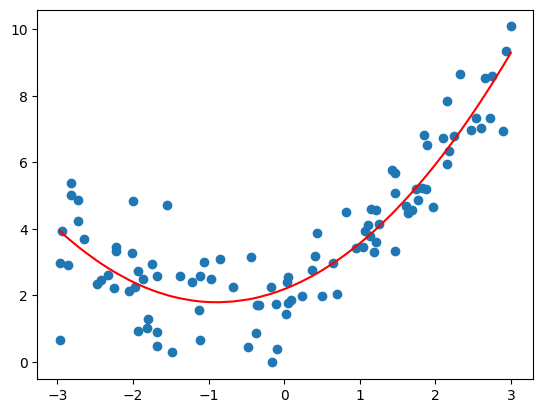

coef: [0.88407972 0.49609386]
intercept: 2.1843461886367503


In [23]:
# 模型正好拟合（演示多项式特征完全匹配真实生成关系的情况）
def fitting():
    # 设置随机种子，保证每次实验结果一致
    np.random.seed(22)
    
    # 1. 准备数据 X，y，并人为增加噪声
    # 创建100个均匀分布在[-3, 3]区间的数值作为自变量特征
    x = np.random.uniform(-3, 3, size=100)
    # 生成因变量y，其中包括一个二次项、一次项和常数项，并添加正态分布的随机噪声
    # 模型真实关系: y = 0.5*x^2 + x + 2 + 噪声
    y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, size=100)
    
    # 2. 实例化线性回归模型
    model = LinearRegression()
    
    # 3. 模型训练阶段
    # 线性回归模型fit方法要求输入特征为二维[n_samples, n_features]，因此需要转换
    # reshape(-1, 1)将一维x转为二维矩阵X，行为样本数，列为特征数（这里只有一个原始特征）
    X = x.reshape(-1, 1)
    print(X.shape)  # 输出转化后的X的形状，(100, 1)

    # 增加模型的多项式能力，将x和x的平方拼接，令特征包含一次和二次两部分
    # np.hstack会把两个(100, 1)的矩阵合并成(100, 2): [x, x^2]
    X2 = np.hstack([X, X ** 2])
    print(X2.shape)  # 输出二次特征后的X2形状，(100, 2)

    # 训练模型，学习权重参数
    model.fit(X2, y)
    
    # 4. 使用训练好的模型进行预测
    y_predict = model.predict(X2)

    # 5. 模型评估：计算均方误差（MSE），数值越小拟合越好
    mse = mean_squared_error(y, y_predict)
    print("正好拟合MSE:", mse)
    
    # 6. 可视化：绘制原始点和预测曲线
    # 散点图：原始样本 (x, y)
    plt.scatter(x, y)
    # 为了让预测曲线平滑且不杂乱，x需要从小到大排序，并按照排序后的索引显示预测结果
    plt.plot(np.sort(x), y_predict[np.argsort(x)], color='r')
    plt.show()
    
    print("coef:", model.coef_)      # [w1, w2] 对应 x 和 x^2
    print("intercept:", model.intercept_)  # b

# 调用函数运行演示
fitting()

原始特征X的形状: (100, 1)
多项式扩展后X2的形状: (100, 10)
完美拟合MSE: 0.8144736129032126


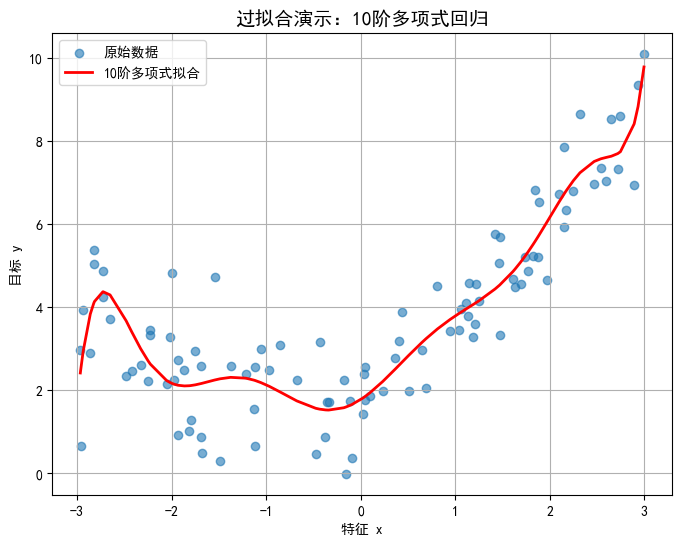

In [ ]:
# ========== 过拟合（Overfitting）演示函数 ===========
# 目的：展示高阶多项式回归可能导致的过拟合问题
# 过拟合：模型在训练数据上表现很好，但在新数据上表现差

def over_fitting():
    """
    过拟合演示函数
    使用高阶多项式回归（10阶）来拟合带噪声的二次函数数据
    展示过拟合的典型特征：训练误差很小，但泛化能力差
    并且输出中文标题和标签，确保显示为中文
    """

    # ========== 步骤1：设置随机种子（Random Seed）==========
    np.random.seed(22)  # 设置NumPy随机种子，保证可复现

    # ========== 步骤2：生成模拟数据（Data Generation）==========
    x = np.random.uniform(-3, 3, size=100)  # x ∈ [-3, 3]，均匀分布
    y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, size=100)  # y真实关系+噪声

    # ========== 步骤3：创建线性回归模型 ==========
    model = LinearRegression()

    # ========== 步骤4：特征工程（多项式扩展）==========
    X = x.reshape(-1, 1)
    print("原始特征X的形状:", X.shape)
    X2 = np.hstack([X] + [X**i for i in range(2, 11)])  # (100,10)，包含x^1到x^10
    print("多项式扩展后X2的形状:", X2.shape)

    # ========== 步骤5：模型训练 ==========
    model.fit(X2, y)

    # ========== 步骤6：模型预测 ==========
    y_predict = model.predict(X2)

    # ========== 步骤7：模型评估 ==========
    mse = mean_squared_error(y, y_predict)
    print("完美拟合MSE:", mse)

    # ========== 步骤8：结果可视化 ==========
    # 添加中文字体设置，防止中文乱码，推荐优先仿宋、微软雅黑、宋体等
    # 注意：matplotlib 3.x后已支持简化的字体设置
    import matplotlib
    matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
    matplotlib.rcParams['axes.unicode_minus'] = False    # 正常显示负号

    # 绘制原始数据散点图
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, label='原始数据')
    # 拟合曲线排序并可视化
    x_sorted = np.sort(x)
    # 这行代码的作用是：为绘制10阶多项式拟合曲线时，确保横坐标x升序排列，相应地让拟合的y值也与x一一对应，实现曲线平滑显示
    # np.argsort(x)会返回数组x按升序排序后的下标（索引），
    # y_predict[np.argsort(x)] 等价于将y_predict的顺序打乱，和x排序后顺序一一对应，
    # 这样plt.plot(x_sorted, y_sorted_predict)就能画出随x升序变化的平滑拟合曲线
    y_sorted_predict = y_predict[np.argsort(x)]
    plt.plot(x_sorted, y_sorted_predict, color='r', linewidth=2, label='10阶多项式拟合')
    # 中文标签/标题
    plt.xlabel('特征 x')
    plt.ylabel('目标 y')
    plt.title('过拟合演示：10阶多项式回归', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

# ========== 函数调用 ==========
over_fitting()

# ========== 过拟合分析 ==========
# 这个例子展示了典型的过拟合现象：
# 1. 使用高阶多项式（10阶）拟合简单二次关系
# 2. 训练误差很小（完美拟合训练数据）
# 3. 但模型过于复杂，在新数据上表现差
# 4. 拟合曲线过度扭曲，跟随每一个噪声点

# 过拟合的解决方法：
# 1. 降低模型复杂度（减少多项式阶数）
# 2. 使用正则化（Ridge回归、Lasso回归）
# 3. 增加训练数据
# 4. 交叉验证选择最佳复杂度
